# Persian Traffic Sign Recognition<br>
### Taha Abbaszadeh & Mahsa Sheikhi
<br>


In [1]:
import os
import random

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Paths & config<br>


In [4]:
train_dir = r'C:\Users\Taha\Desktop\folder\un\cv\project\archive\PTSD_Recognition\PTSD_Recognition\train'
test_dir = r'C:\Users\Taha\Desktop\folder\un\cv\project\archive\PTSD_Recognition\PTSD_Recognition\test'
csv_path = r'C:\Users\Taha\Desktop\folder\un\cv\project\archive\testset_CSV.csv'
output_dir = r'C:\Users\Taha\Desktop\folder\un\cv\project\archive\PTSD_Recognition\outputs'
os.makedirs(output_dir, exist_ok=True)

In [5]:
IMG_SIZE = 96      # traffic-sign shapes don't need 256x256; this is far lighter
BATCH_SIZE = 32
EPOCHS = 60        # EarlyStopping will usually stop well before this

### Build (path, label) tables for train and test<br>
<br>


In [6]:
test_labels = pd.read_csv(csv_path)

In [7]:
LABEL_CORRECTIONS = {
    'NO Waitin': 'NO Waiting',
}

In [8]:
def strip_index_prefix(folder_name: str) -> str:
    # "0_Compulsory Keep BothSide" -> "Compulsory Keep BothSide"
    parts = folder_name.split('_', 1)
    if len(parts) == 2 and parts[0].isdigit():
        return parts[1]
    return folder_name

In [9]:
train_rows = []
for folder_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, folder_name)
    if not os.path.isdir(class_path):
        continue
    class_name = strip_index_prefix(folder_name)
    for img_name in os.listdir(class_path):
        train_rows.append([os.path.join(class_path, img_name), class_name])

In [10]:
train_df = pd.DataFrame(train_rows, columns=["image_path", "label"])

In [11]:
test_df = test_labels.copy()
test_df['image_path'] = test_df['file'].apply(
    lambda f: os.path.join(test_dir, f.replace('.JPG', '.jpg'))
)
test_df = test_df.rename(columns={'species': 'label'})
test_df['label'] = test_df['label'].replace(LABEL_CORRECTIONS)

In [12]:
print("Train class counts:\n", train_df['label'].value_counts())
print("\nTest class counts:\n", test_df['label'].value_counts())

Train class counts:
 label
NO Stopping                 1075
Pedestrain                  1014
No Entry                     930
Compulsory Keep Right        703
One way Traffic              684
Cycle crossing               662
Compulsory Keep BothSide     573
Right Margin                 506
Roundabouts                  497
Maximum Speed 30             477
Right Turn Prohibited        436
Danger                       399
Left Margin                  392
Give Way                     384
Compulsory Keep Left         369
School Crossing              334
STOP                         329
Hump                         303
Pedestrian crossing          297
Slow                         292
Maximum Speed 60             288
School                       283
Left Turn Prohibited         270
U-turn Prohibited            259
Maximum Speed 50             250
Park Forbidden               229
MotorCycle Prohibited        221
NO Waiting                   210
Speed Camera                 200
No Horn         

### Label encoding (one shared encoder so train/val/test indices line up)<br>


In [13]:
encoder = LabelEncoder()
encoder.fit(train_df['label'])
class_names = list(encoder.classes_)
num_classes = len(class_names)

In [14]:
unseen = set(test_df['label']) - set(class_names)
if unseen:
    raise ValueError(f"Test set has classes not present in train: {unseen}")

In [15]:
train_df['label_id'] = encoder.transform(train_df['label'])
test_df['label_id'] = encoder.transform(test_df['label'])

In [16]:
print(f"\nNumber of classes: {num_classes}")
print(class_names)


Number of classes: 43
['Compulsory Keep BothSide', 'Compulsory Keep Left', 'Compulsory Keep Right', 'Cycle crossing', 'Danger', 'Give Way', 'Hump', 'Left Bend', 'Left Margin', 'Left Turn Prohibited', 'Maximum Speed 30', 'Maximum Speed 40', 'Maximum Speed 50', 'Maximum Speed 60', 'Maximum Speed 70', 'Maximum Speed 80', 'Maximum Speed 90', 'MotorCycle Prohibited', 'NO Stopping', 'NO Waiting', 'No Entry', 'No Horn', 'One way Traffic', 'Park', 'Park Forbidden', 'Pedestrain', 'Pedestrian crossing', 'Right Bend', 'Right Margin', 'Right Turn Prohibited', 'Road Work', 'Roundabouts', 'STOP', 'School', 'School Crossing', 'Side Road Right', 'Slow', 'Speed Camera', 'Truck Prohibited', 'Two Way Traffic', 'U-Turn', 'U-Turn Allowed', 'U-turn Prohibited']


### Stratified train/validation split (the test set stays completely untouched)<br>


In [17]:
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['label_id'],
    random_state=SEED,
)
print(f"train: {len(train_split_df)}  val: {len(val_split_df)}  test: {len(test_df)}")

train: 12244  val: 2161  test: 2421


### Image pre-processing (OpenCV side: resize + CLAHE on the luma channel)<br>


In [ ]:
def preprocess_image(path: str) -> np.ndarray:
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")

    # resize (consistent square size, area interpolation = cleaner downscale)
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # CLAHE on luma channel -> evens out lighting/contrast without distorting color
    yuv = cv2.cvtColor(resized, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(yuv[:, :, 0])

    rgb = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
    return rgb.astype(np.float32) / 255.0

In [19]:
def _load_and_preprocess(path_tensor):
    path = path_tensor.numpy().decode('utf-8')
    return preprocess_image(path)

In [20]:
def tf_load_image(path, label):
    img = tf.py_function(func=_load_and_preprocess, inp=[path], Tout=tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    label = tf.cast(label, tf.int32)
    return img, label

In [21]:
def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = df['image_path'].tolist()
    labels = df['label_id'].tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [22]:
train_ds = make_dataset(train_split_df, training=True)
val_ds = make_dataset(val_split_df, training=False)
test_ds = make_dataset(test_df, training=False)

sanity check

In [23]:
for xb, yb in train_ds.take(1):
    print('train batch:', xb.shape, xb.dtype, '| labels:', yb.shape, yb.dtype)

train batch: (32, 96, 96, 3) <dtype: 'float32'> | labels: (32,) <dtype: 'int32'>


### Visual sanity check: a few preprocessed training images<br>


In [24]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (xb, yb) in zip(axes.flat, [(xb, yb) for xb, yb in train_ds.unbatch().take(8)]):
    ax.imshow(xb.numpy())
    ax.set_title(class_names[int(yb.numpy())], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sample_preprocessed_images.png'), dpi=150)
plt.close()

### Model: CNN with built-in, sign-safe augmentation<br>


In [ ]:
def build_model(input_shape, n_classes):
    augmentation = keras.Sequential([
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(0.15, value_range=(0.0, 1.0)),
    ], name="augmentation")
    inputs = keras.Input(shape=input_shape)
    x = augmentation(inputs)
    for filters in (32, 64, 128):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="traffic_sign_cnn")

In [26]:
model = build_model((IMG_SIZE, IMG_SIZE, 3), num_classes)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "traffic_sign_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,979 (1.27 MB)

 Trainable params: 331,531 (1.26 MB)

 Non-trainable params: 448 (1.75 KB)

### Train<br>


In [27]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        os.path.join(output_dir, 'best_model.keras'),
        monitor='val_accuracy', save_best_only=True,
    ),
]

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    shuffle=False,  # dataset already shuffle
    callbacks=callbacks,
)

Epoch 1/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 104s 260ms/step - accuracy: 0.3422 - loss: 2.3370 - val_accuracy: 0.2985 - val_loss: 2.5422 - learning_rate: 0.0010
Epoch 2/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 94s 244ms/step - accuracy: 0.6446 - loss: 1.1707 - val_accuracy: 0.7492 - val_loss: 0.8373 - learning_rate: 0.0010
Epoch 3/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 111s 289ms/step - accuracy: 0.7743 - loss: 0.7237 - val_accuracy: 0.8343 - val_loss: 0.5313 - learning_rate: 0.0010
Epoch 4/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 133s 348ms/step - accuracy: 0.8363 - loss: 0.5233 - val_accuracy: 0.8570 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 5/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 132s 344ms/step - accuracy: 0.8795 - loss: 0.3923 - val_accuracy: 0.9075 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 6/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 140s 365ms/step - accuracy: 0.9031 - loss: 0.3180 - val_accuracy: 0.9172 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 7/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 136s 356ms/step - accurac

KeyboardInterrupt: 

### Training curves<br>


NameError: name 'history' is not defined

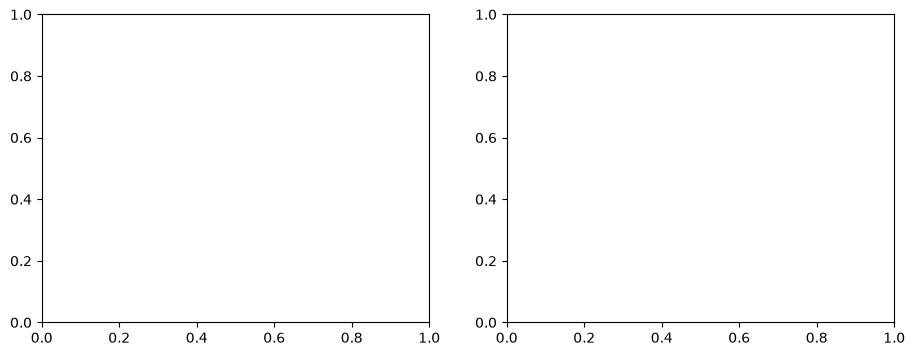

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

In [ ]:
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'training_curves.png'), dpi=150)
plt.close()

### Test evaluation + confusion matrix<br>


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

In [ ]:
y_true = test_df['label_id'].to_numpy()
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print(report)
with open(os.path.join(output_dir, 'classification_report.txt'), 'w') as f:
    f.write(report)

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(max(10, num_classes), max(4, num_classes * 0.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

In [ ]:
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

In [ ]:
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

In [ ]:
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=150)
plt.close()
print(f"Saved figures and report to: {output_dir}")

### Save final model + label mapping (for later inference)<br>


In [ ]:
model.save(os.path.join(output_dir, 'final_model.keras'))
pd.Series(class_names).to_csv(os.path.join(output_dir, 'class_names.csv'), index_label='label_id', header=['label'])
print("Done.")